# Velocity Cycle Co. — Sales & Customer Analytics

In [192]:
# MODULE SETUP
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import pandas as pd
import os
import re
os.getcwd()

'C:\\Users\\Lenovo\\Projects\\Portfolio'

In [193]:
# OUTPUT FOLDER SETUP
os.makedirs("images", exist_ok=True)

In [194]:
# READING THE DATA 
path = r"D:\University\Fourth Year\Fourth Year\Career Prep\Portfolio\Velocity Cycle Co"
files = []
for item in os.listdir(path):
    if item.endswith(".csv"):
        files.append(item)        
dict = {}

for item in files:
    data =  pd.read_csv(os.path.join(path, item))
    dict[re.sub(r"\d+\s-\s|\.csv$", "", item)] = data
    if item == "0 - KPI Cards (Transaction, Revenue, AOV).csv":
        dict["KPI"] = dict.pop("KPI Cards (Transaction, Revenue, AOV)")

print("Nama File\n")
for id, item in enumerate(dict.keys()):
    print(f"{id} - {item}")

Nama File

0 - KPI
1 - Monthly Revenue
2 - Quartal Revenue
3 - Revenue and AOV, Offline or Online
4 - Product Category and Revenue
5 - RFM
6 - Shopping Pattern by RFM
7 - Region
8 - Top 10 Products
9 - Segment Order Count by Channel


## Monthly Revenue

In [195]:
# MONTHLY REVENUE
monthly = dict["Monthly Revenue"]
x_pos = range(len(monthly))
avg_revenue = monthly["revenue"].mean()

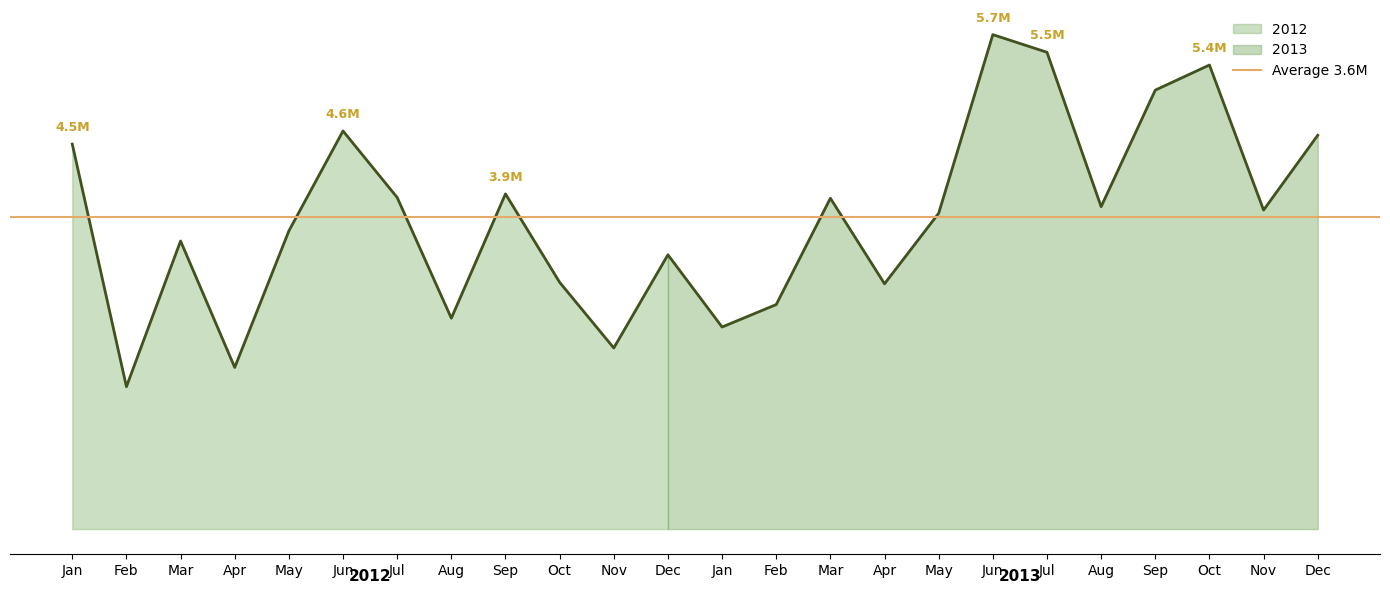

In [196]:
import calendar

plt.figure(figsize=(14, 6))

month_labels = [calendar.month_abbr[m] for m in monthly["month"]]

plt.plot(x_pos, monthly["revenue"], color="#41521F", linewidth=2)

plt.fill_between(x_pos[:12], monthly["revenue"][:12], color="#7FB069", alpha=0.4, label="2012")
plt.fill_between(x_pos[11:], monthly["revenue"][11:], color="#6EA357", alpha=0.4, label="2013")

plt.axhline(avg_revenue, color="#E6AA68", linewidth=1.5, label=f"Average {avg_revenue/1e6:.1f}M")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.yaxis.set_visible(False)

plt.xticks(x_pos, month_labels)

top3_2012 = monthly[monthly["year"] == 2012]["revenue"].nlargest(3)
top3_2013 = monthly[monthly["year"] == 2013]["revenue"].nlargest(3)
top3_indices = list(top3_2012.index) + list(top3_2013.index)
for idx in top3_indices:
    x = idx
    y = monthly["revenue"].iloc[idx]
    label = f"{y/1e6:.1f}M"
    plt.text(x, y + 150000, label, ha='center', fontsize=9, fontweight='bold', color="#C9A227")

plt.text(5.5, -0.05, "2012", transform=ax.get_xaxis_transform(), ha='center', fontsize=11, fontweight='bold')
plt.text(17.5, -0.05, "2013", transform=ax.get_xaxis_transform(), ha='center', fontsize=11, fontweight='bold')

plt.legend(frameon=False)
plt.tight_layout()
plt.savefig("images/revenue_trend_2012_2013.png", dpi=300, bbox_inches='tight')
plt.show()

## Quarterly Revenue

In [197]:
# QUARTERLY REVENUE
quarterly = dict["Quartal Revenue"]
quarterly_2012 = quarterly[quarterly["year"] == 2012]
quarterly_2013 = quarterly[quarterly["year"] == 2013]

quarterly

,year,quarter,revenue,avg_quarterly_revenue,variance_pct
0,2012,1,9.443737e+06,9418925.08,0.26
1,2012,2,9.935495e+06,9418925.08,5.48
2,2012,3,1.016441e+07,9418925.08,7.91
3,2012,4,8.132061e+06,9418925.08,-13.66
4,2013,1,8.771886e+06,12241471.99,-28.34
5,2013,2,1.222506e+07,12241471.99,-0.13
6,2013,3,1.433932e+07,12241471.99,17.14
7,2013,4,1.362962e+07,12241471.99,11.34


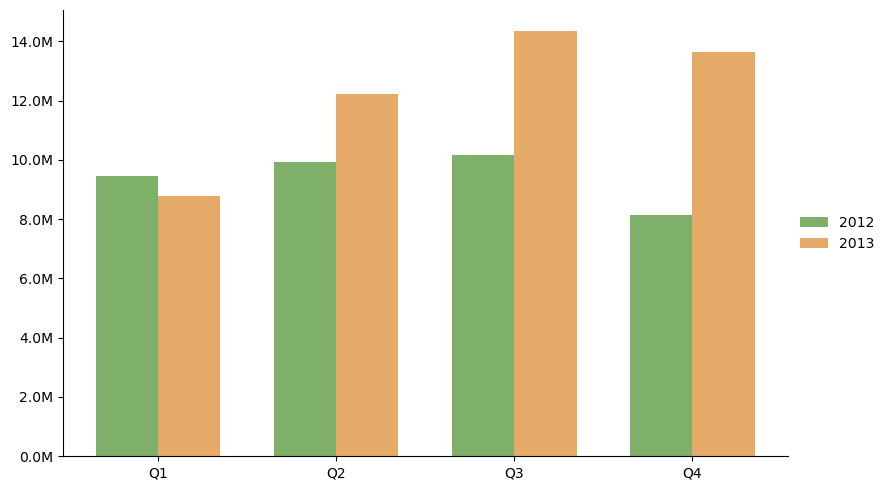

In [198]:
plt.figure(figsize=(9, 5))

x = np.arange(4)
width = 0.35

plt.bar(
    x - width/2,
    quarterly_2012["revenue"],
    width=width,
    label="2012", color="#7FB069"
)

plt.bar(
    x + width/2,
    quarterly_2013["revenue"],
    width=width,
    label="2013", color="#E6AA68"
)

ax = plt.gca()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
)

plt.xticks(
    x,
    ["Q1", "Q2", "Q3", "Q4"]
)

plt.legend(
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=False
)

plt.grid(False)

plt.tight_layout()
plt.savefig("images/quarterly_revenue_2012_2013.png", dpi=300, bbox_inches='tight')
plt.show()

## AOV and Transaction Count by Channel

In [199]:
# AOV and Transaction Count by Channel
KPI = dict["Revenue and AOV, Offline or Online"]
titles = ['year','quarter','total_transaction','avg_order_value']
TAOV_OFFLINE = KPI[KPI['onlineorderflag'] == False][titles]
TAOV_ONLINE = KPI[KPI['onlineorderflag'] == True][titles]
avg_aov = round(KPI['avg_order_value'].mean(),2)
TAOV_OFFLINE

,year,quarter,total_transaction,avg_order_value
1,2012,1,265,27656.906148
3,2012,2,279,28435.033716
5,2012,3,317,27510.473540
7,2012,4,311,21320.940814
9,2013,1,314,22633.079008
11,2013,2,383,26198.797899
13,2013,3,454,24421.207122
15,2013,4,447,19862.936232


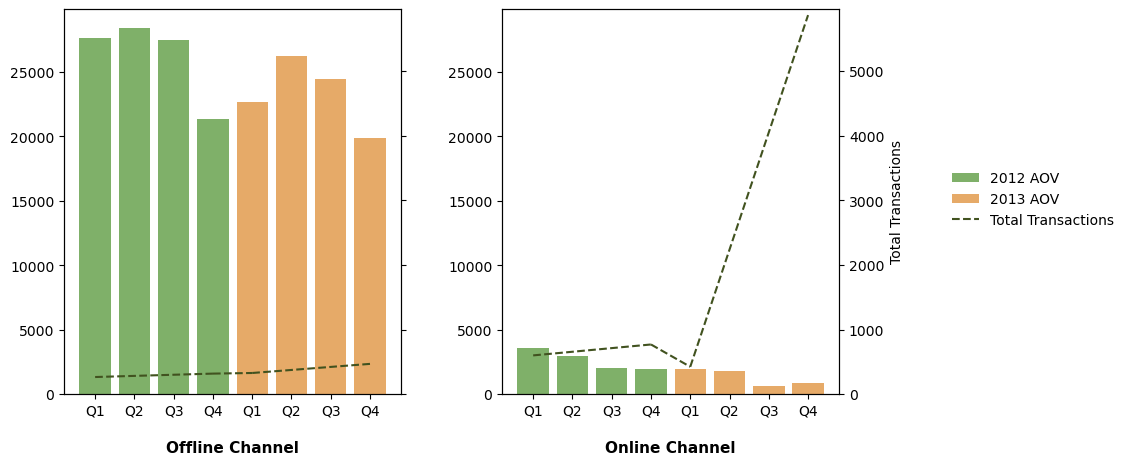

In [200]:
# TOTAL TRANSACTIONS AND AOV
x = range(len(TAOV_OFFLINE))
colors = [
    "#7FB069" if i < 4 else "#E6AA68"
    for i in range(len(TAOV_OFFLINE))
]
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.subplots_adjust(wspace=0.3)

# BAR PLOTS
axes[0].bar(x, TAOV_OFFLINE['avg_order_value'], color=colors)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"Q{q}" for q in TAOV_OFFLINE["quarter"]])
axes[1].bar(x, TAOV_ONLINE['avg_order_value'], color=colors)
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"Q{q}" for q in TAOV_ONLINE["quarter"]])
ymax = max(TAOV_OFFLINE['avg_order_value'].max(), TAOV_ONLINE['avg_order_value'].max())
axes[0].set_ylim(0, ymax * 1.05)
axes[1].set_ylim(0, ymax * 1.05)

# TRENDLINES (total_transaction, split by year)
x_2012 = list(range(4))
x_2013 = list(range(4, 8))

z_off_12 = np.polyfit(x_2012, TAOV_OFFLINE['total_transaction'][:4], 1)
z_off_13 = np.polyfit(x_2013, TAOV_OFFLINE['total_transaction'][4:], 1)
trend_off_12 = np.poly1d(z_off_12)
trend_off_13 = np.poly1d(z_off_13)

z_on_12 = np.polyfit(x_2012, TAOV_ONLINE['total_transaction'][:4], 1)
z_on_13 = np.polyfit(x_2013, TAOV_ONLINE['total_transaction'][4:], 1)
trend_on_12 = np.poly1d(z_on_12)
trend_on_13 = np.poly1d(z_on_13)

trend_ymax = max(
    TAOV_OFFLINE['total_transaction'].max(),
    TAOV_ONLINE['total_transaction'].max()
)

ax0b = axes[0].twinx()
ax0b.plot(x_2012, trend_off_12(x_2012), color="#41521F", linestyle="--", linewidth=1.5)
ax0b.plot(x_2013, trend_off_13(x_2013), color="#41521F", linestyle="--", linewidth=1.5)
ax0b.set_ylim(0, trend_ymax * 1.05)
ax0b.set_ylabel("Total Transactions")

ax1b = axes[1].twinx()
ax1b.plot(x_2012, trend_on_12(x_2012), color="#41521F", linestyle="--", linewidth=1.5)
ax1b.plot(x_2013, trend_on_13(x_2013), color="#41521F", linestyle="--", linewidth=1.5)
ax1b.set_ylim(0, trend_ymax * 1.05)
ax1b.set_ylabel("Total Transactions")

year_patches = [
    Patch(facecolor="#7FB069", label="2012 AOV"),
    Patch(facecolor="#E6AA68", label="2013 AOV"),
]
trend_line = Line2D([0], [0], color="#41521F", linestyle="--", linewidth=1.5, label="Total Transactions")

fig.legend(
    handles=year_patches + [trend_line],
    loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False
)

axes[0].text(0.5, -0.15, "Offline Channel", transform=axes[0].transAxes, ha='center', fontsize=11, fontweight='bold')
axes[1].text(0.5, -0.15, "Online Channel", transform=axes[1].transAxes, ha='center', fontsize=11, fontweight='bold')

ax0b.set_yticklabels([])
ax0b.set_ylabel("")
ax0b.plot([x_2012[-1], x_2013[0]], [trend_off_12(x_2012[-1]), trend_off_13(x_2013[0])],
          color="#41521F", linestyle="--", linewidth=1.5)

ax1b.plot([x_2012[-1], x_2013[0]], [trend_on_12(x_2012[-1]), trend_on_13(x_2013[0])],
          color="#41521F", linestyle="--", linewidth=1.5)

fig.savefig("images/revenue_by_channel_2012_2013.png", dpi=300, bbox_inches='tight')
plt.show()

## Revenue by Product Category

In [201]:
product = dict["Product Category and Revenue"]
product

,productcategoryid,name,revenue,revenue_pct
0,1,Bikes,6.525235e+07,84.58
1,2,Components,9.493693e+06,12.31
2,3,Clothing,1.623277e+06,2.10
3,4,Accessories,7.774645e+05,1.01


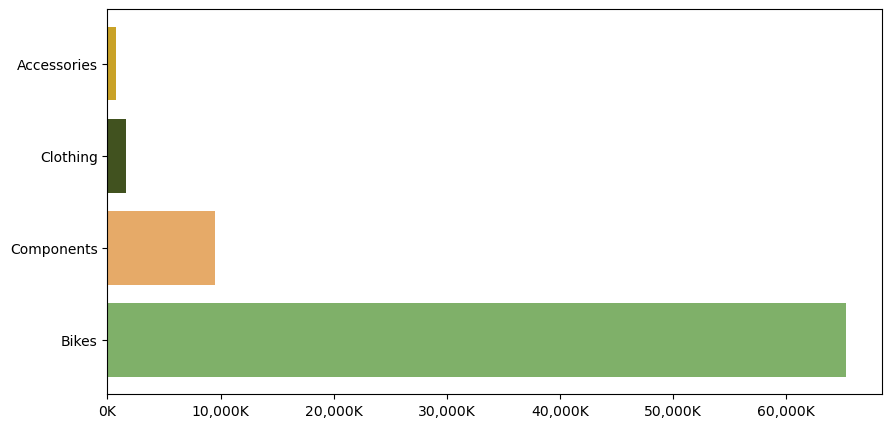

In [202]:
plt.figure(figsize=(10,5))
colors = ["#7FB069", "#E6AA68", "#41521F", "#C9A227"]
plt.barh(product['name'], product['revenue'], color=colors)
ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e3:,.0f}K'))
plt.savefig("images/revenue_by_product_category.png", dpi=300, bbox_inches='tight')
plt.show()

## Customer Segmentation (RFM)

In [203]:
rfm = dict['RFM'].sort_values('revenue', ascending=False)
rfm

,segment,customer_count,customer_pct,revenue
0,Champion,600,4.82,79140688.96
1,Big Spender,2724,21.87,26295323.48
2,At Risk,8978,72.08,10904502.48
3,Lapsed Champion,5,0.04,481023.15
4,Loyal,149,1.20,117874.74


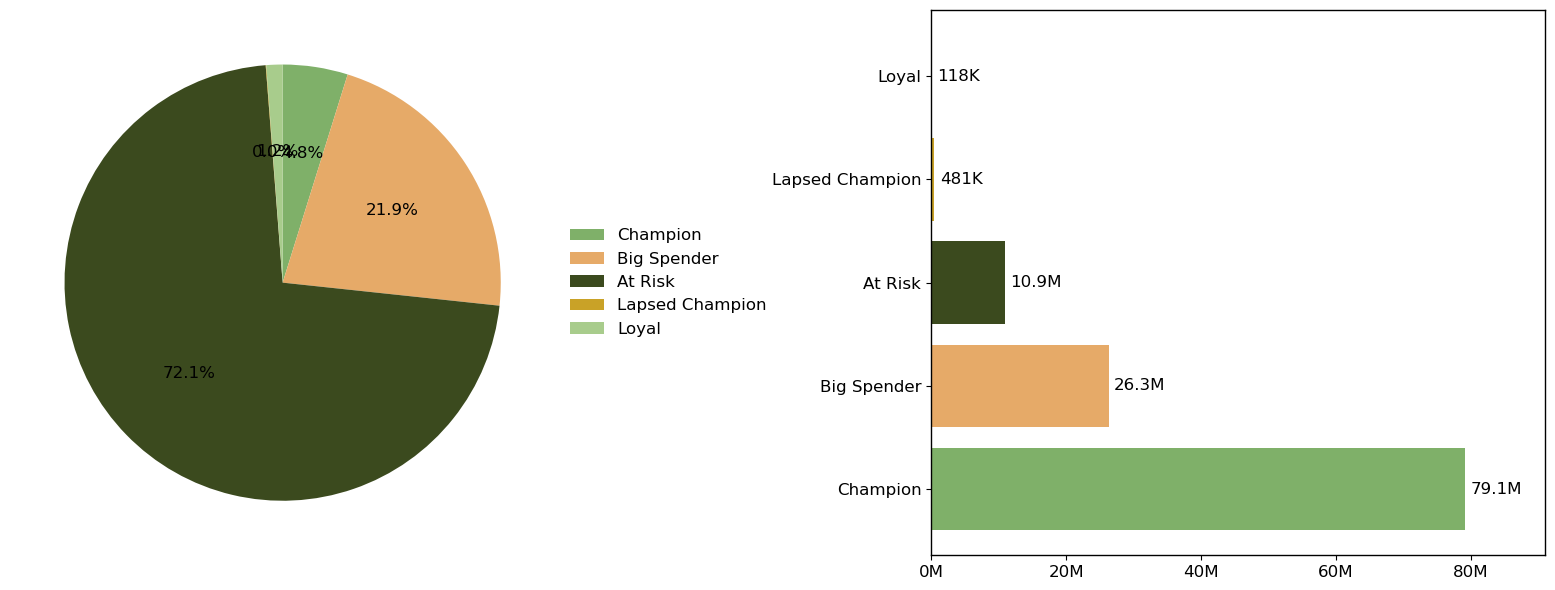

In [204]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

rfm = dict['RFM'].sort_values('revenue', ascending=False)

colors = {
    "Champion": "#7FB069",
    "Big Spender": "#E6AA68",
    "At Risk": "#3B4A1E",
    "Lapsed Champion": "#C9A227",
    "Loyal": "#A8CC8C",
}
bar_colors = rfm["segment"].map(colors)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.pie(
    rfm["customer_pct"],
    colors=bar_colors,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    textprops={"fontsize": 12},
)
ax1.legend(
    labels=rfm["segment"],
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
    fontsize=12,
    frameon=False,
)
ax1.set_aspect("equal")

bars = ax2.barh(rfm["segment"], rfm["revenue"], color=bar_colors)

def fmt_value(v):
    if v >= 1_000_000:
        return f"{v/1_000_000:.1f}M"
    else:
        return f"{v/1_000:.0f}K"

for bar, value in zip(bars, rfm["revenue"]):
    ax2.text(
        bar.get_width() + rfm["revenue"].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        fmt_value(value),
        va="center",
        ha="left",
        fontsize=12,
    )

ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1_000_000:.0f}M"))
ax2.set_xlim(0, rfm["revenue"].max() * 1.15)
ax2.tick_params(axis="both", labelsize=12)

for spine in ax2.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1)

plt.tight_layout()
plt.savefig("segment_pie_and_bar.png", dpi=150, bbox_inches="tight")
plt.show()

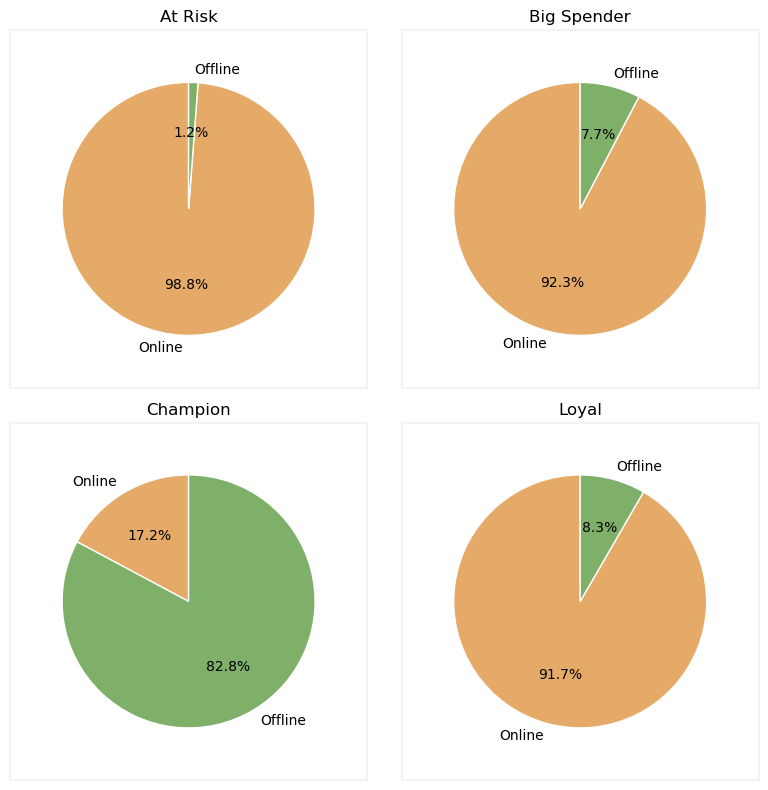

In [205]:
segment_channel = dict["Segment Order Count by Channel"]
segment_channel = segment_channel[segment_channel["segment"] != "Lapsed Champion"]
segments = segment_channel["segment"].unique()
n = len(segments)  # 4 segments -> 2x2 grid
ncols = 2
nrows = -(-n // ncols)  # ceil division
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = axes.flatten()
colors = {"offline": "#7FB069", "online": "#E6AA68"}
for i, seg in enumerate(segments):
    ax = axes[i]
    sub = segment_channel[segment_channel["segment"] == seg]
    labels, sizes, plot_colors = [], [], []
    for _, row in sub.iterrows():
        label = "Online" if row["onlineorderflag"] else "Offline"
        labels.append(label)
        sizes.append(row["order_count"])
        plot_colors.append(colors["online"] if row["onlineorderflag"] else colors["offline"])
    ax.pie(
        sizes,
        labels=labels,
        autopct="%1.1f%%",
        colors=plot_colors,
        startangle=90,
        radius=0.85,
        wedgeprops={"edgecolor": "white", "linewidth": 1},
    )
    ax.set_title(seg, fontsize=12)
    # square frame around each pie
    ax.set_frame_on(True)
    ax.axis("on")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("#F1F3F4")
        spine.set_linewidth(1.5)
    ax.set_aspect("equal")
for j in range(n, len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.savefig("segment_order_count_pies.png", dpi=150, bbox_inches="tight")
plt.show()

## Shopping Patterns by Segmentation

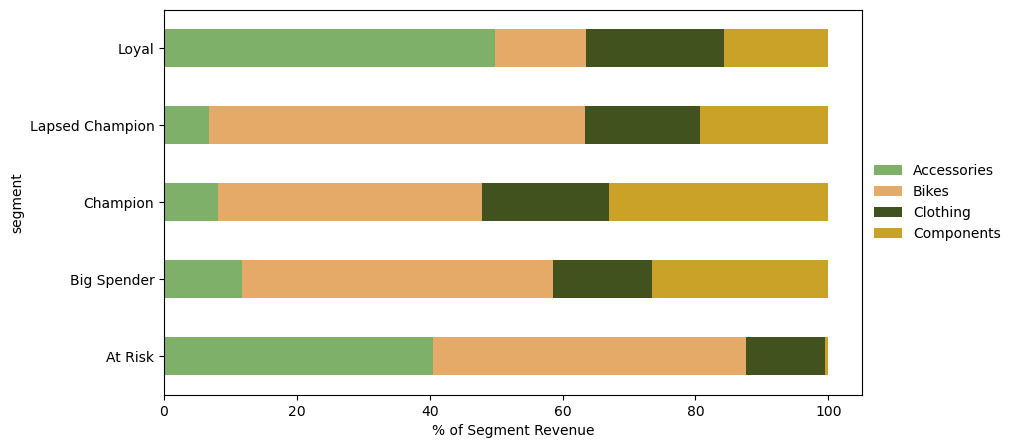

In [206]:
# SHOPPING PATTERN ANALYSIS
rfm_analysis = dict['Shopping Pattern by RFM']
pivot = rfm_analysis.pivot(index='segment', columns='name', values='rev')
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

ax = pivot_pct.plot(kind='barh', stacked=True, figsize=(9,5), color=["#7FB069","#E6AA68","#41521F","#C9A227"])
plt.xlabel("% of Segment Revenue")
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False)
plt.savefig("images/shopping_patterns_by_segmentation.png", dpi=300, bbox_inches='tight')
plt.show()

## Revenue by Region

In [207]:
region = dict['Region'].sort_values(['total_revenue', 'total_orders'], ascending=False)
region

,countryregioncode,total_revenue,total_orders
0,US,5.065110e+07,6948
1,CA,1.361042e+07,2344
2,AU,7.050290e+06,3907
3,FR,6.014507e+06,1563
4,GB,5.837948e+06,1851
5,DE,3.477320e+06,1484


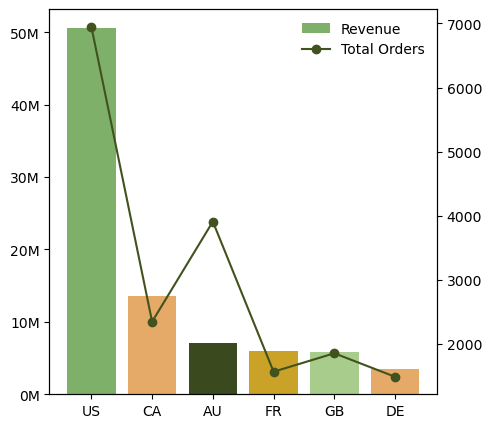

In [210]:
fig, ax1 = plt.subplots(figsize=(5,5))

region_colors = ["#7FB069", "#E6AA68", "#3B4A1E", "#C9A227", "#A8CC8C", "#E6AA68"]

ax1.bar(region['countryregioncode'], region['total_revenue'], color=region_colors)
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

ax2 = ax1.twinx()
ax2.plot(region['countryregioncode'], region['total_orders'], color="#41521F", marker='o')

bar_patch = Patch(facecolor="#7FB069", label="Revenue")
line_patch = Line2D([0], [0], color="#41521F", marker='o', linewidth=1.5, label="Total Orders")
ax1.legend(handles=[bar_patch, line_patch], loc='upper right', frameon=False)

fig.savefig("images/revenue_by_region.png", dpi=300, bbox_inches='tight')
plt.show()